In [25]:
#import libraries are below that are using 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [27]:
#here we are reading data table and the excel file

df = pd.read_excel('overbooking.xlsx', skiprows=1)
df

,flight,Booked,No shows,Unnamed: 3,bumped,total compensation,Unnamed: 6,compensation per bumped passenger
0,1,255,12,NaN,0,0,NaN,0.000000
1,2,255,17,NaN,0,0,NaN,0.000000
2,3,255,12,NaN,0,0,NaN,0.000000
3,4,255,17,NaN,0,0,NaN,0.000000
4,5,255,17,NaN,0,0,NaN,0.000000
...,...,...,...,...,...,...,...,...
495,496,295,15,NaN,30,22427,NaN,747.566667
496,497,295,18,NaN,27,18344,NaN,679.407407
497,498,295,14,NaN,31,23805,NaN,767.903226
498,499,295,10,NaN,35,30008,NaN,857.371429


In [29]:
#for the dataframe columns that are unnamed and don't have any relevance, drop them completely

#unnamed --> no relevance

df = df.drop(columns=['Unnamed: 3', 'Unnamed: 6'])
df

,flight,Booked,No shows,bumped,total compensation,compensation per bumped passenger
0,1,255,12,0,0,0.000000
1,2,255,17,0,0,0.000000
2,3,255,12,0,0,0.000000
3,4,255,17,0,0,0.000000
4,5,255,17,0,0,0.000000
...,...,...,...,...,...,...
495,496,295,15,30,22427,747.566667
496,497,295,18,27,18344,679.407407
497,498,295,14,31,23805,767.903226
498,499,295,10,35,30008,857.371429


## Component I: Airline Overbooking Analysis

**Problem Setup**
- The plane capacity is 250 seats
- The fixed cost is $70,000 per flight
- Every passenger who boards adds $600 to the revenue, and this cost is fully refundable for no-shows
- For passengers who are bumped, the alternative transport cost offsets the $600 ticket revenue plus additional compensation is paid
- The profit formula is:

**Profit Formula**
Profit = (passengers who board × $600) − total compensation paid − $70,000

In [32]:
#intiial details given about the airline analysis --> overbooking situation
#given information about the problem

SEATS          = 250
TICKET_REVENUE = 600
FIXED_COST     = 70_000

In [34]:
#now need to find the PROFIT calc

#index from dataframe --> 
# Revenue only from passengers who board
# No-shows -->  refunded -->  no profit for that end
# Bumped → $600 TICKET REVENUE (total comp) 


#make a new col called boarded where you get the final val
df['boarded'] = df['Booked'] - df['No shows'] - df['bumped']

#made a new column called profit where you apply the original equation and subtract the fixed cost 
df['profit']  = df['boarded'] * TICKET_REVENUE - df['total compensation'] - FIXED_COST


#account for the additional OUTFLOW there

In [36]:
# Expected profit FOR EACH booking level



pbl = (df.groupby('Booked')['profit'].agg(mean='mean', std='std', n='count').reset_index())

#standardize the values for comparasion
pbl['se'] = pbl['std'] / np.sqrt(pbl['n'])

#find the booked values within this section
#find the max index in here
opt_row   = pbl.loc[pbl['mean'].idxmax()]
opt_B_obs = int(opt_row['Booked'])


#CHANGE the original operations with more understandable column names 
print("Expected Profit by Booking Level using Historical Data")

#now given some new columns, rename the original to the new names 


display_pbl = pbl[['Booked','mean','std','n']].rename(columns={'mean':'Avg Profit ($)','std':'Std Dev ($)','n':'N obs'})


#PRINT FINAL TABLE OF VALUES --> convert to the string format
print(display_pbl.to_string(index=False, float_format=lambda x: f'{x:,.0f}'))
print(f"\n>>> Best booking level from observed data : {opt_B_obs} seats")
print(f"Average profit: ${opt_row['mean']:,.0f}")

Expected Profit by Booking Level using Historical Data
 Booked  Avg Profit ($)  Std Dev ($)  N obs
    255          75,169        2,115    100
    265          78,946        1,174    100
    275          76,270        1,881    100
    285          68,274        3,833    100
    295          57,925        5,278    100

>>> Best booking level from observed data : 265 seats
Average profit: $78,946


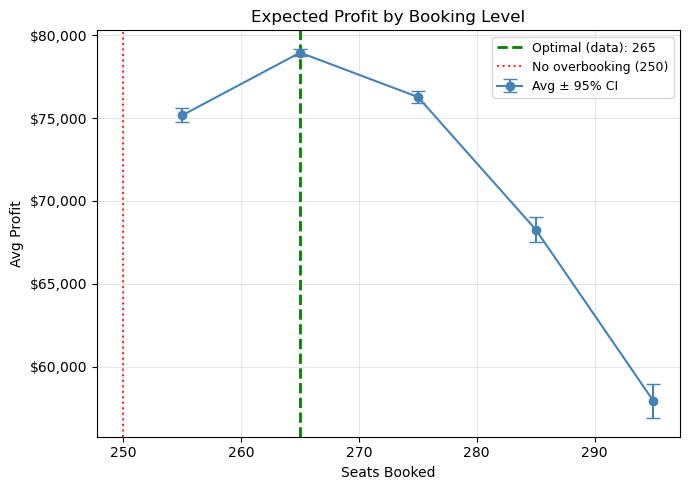

In [38]:
#expected profit using the confidence intervals

#use the confidence intervals to make the overall function more visible
fmt_d = mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')

#add subplots here to make up for the lost plots
fig, ax = plt.subplots(figsize=(7, 5))                     


#now within each of the axes, this is how we want to customize the graphs
ax.errorbar(pbl['Booked'], pbl['mean'], yerr=1.96*pbl['se'],
            fmt='o-', capsize=5, color='steelblue', label='Avg ± 95% CI')
ax.axvline(opt_B_obs, color='green', ls='--', lw=2, label=f'Optimal (data): {opt_B_obs}')
ax.axvline(250, color='red', ls=':', lw=1.5, alpha=0.8, label='No overbooking (250)')

#for the y-axis and x-axis these are some points that show you the average profit
ax.set_title('Expected Profit by Booking Level'); ax.set_xlabel('Seats Booked'); ax.set_ylabel('Avg Profit')
ax.yaxis.set_major_formatter(fmt_d); ax.legend(fontsize=9); ax.grid(alpha=0.3)

#using these specifications use the dotted lines to find the profit at a certain interval
plt.tight_layout(); plt.show()

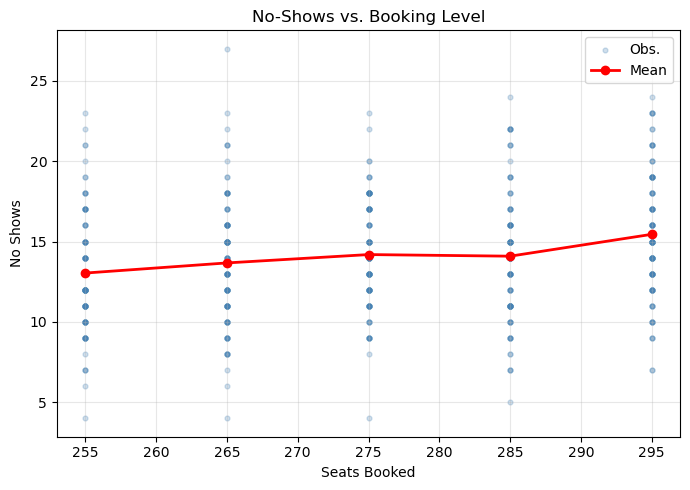

In [39]:
# these are the comparasions with the no-shows 
fig, ax = plt.subplots(figsize=(7, 5))   


#here below is the scatter plot with each of the leveled lines 
ax.scatter(df['Booked'], df['No shows'], alpha=0.25, s=12, color='steelblue', label='Obs.')

#groupby each of the no show parameters
mean_ns = df.groupby('Booked')['No shows'].mean()
ax.plot(mean_ns.index, mean_ns.values, 'r-o', ms=6, lw=2, label='Mean')

#here below is the overall graph 
ax.set_title('No-Shows vs. Booking Level'); ax.set_xlabel('Seats Booked'); ax.set_ylabel('No Shows')

#to describe what each of the colors signify
ax.legend(); ax.grid(alpha=0.3)

#show the layout of the graph below and add the details 
plt.tight_layout(); plt.show()

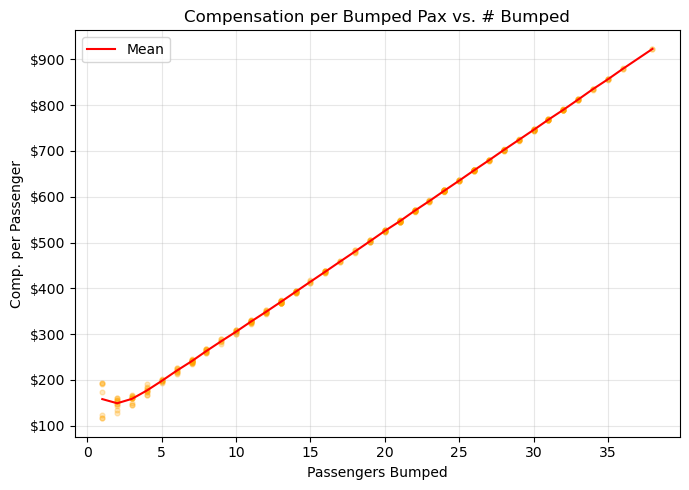

In [40]:
# Compensation per Bumped Pax vs. how many were bumped
fig, ax = plt.subplots(figsize=(7, 5))                      


#filter the dataframe with the bumped section being larger than 0
bdf = df[df['bumped'] > 0]

#create a scatterplot
ax.scatter(bdf['bumped'], bdf['compensation per bumped passenger'], alpha=0.25, s=12, color='orange')

#here is the mean where the groupby statement 
mean_c = bdf.groupby('bumped')['compensation per bumped passenger'].mean()


#here plot the graph 
ax.plot(mean_c.index, mean_c.values, 'r-', lw=1.5, label='Mean')
ax.set_title('Compensation per Bumped Pax vs. # Bumped')
ax.set_xlabel('Passengers Bumped'); ax.set_ylabel('Comp. per Passenger')
ax.yaxis.set_major_formatter(fmt_d); ax.legend(); ax.grid(alpha=0.3)

#layout of the house 
plt.tight_layout(); plt.show()

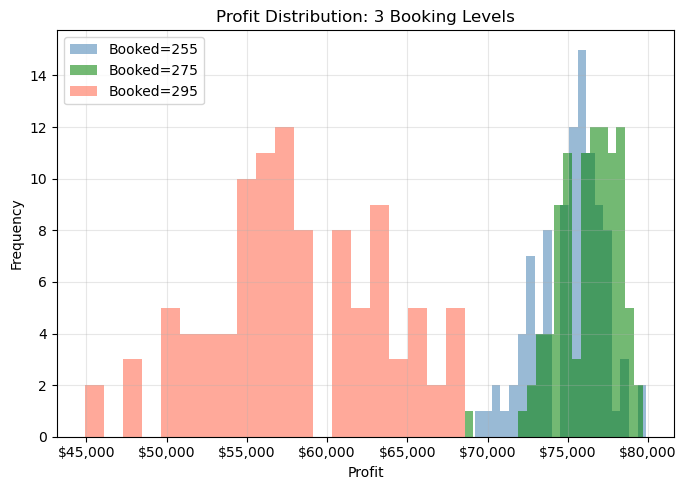

In [41]:
# Profit Distribution at the following 3 booking levels


#here are the subplots with each of the data
fig, ax = plt.subplots(figsize=(7, 5))                          # ← replaces ax = axes[1, 1]

#for each of the for loops in a zipped folder 
for b, c in zip([255, 275, 295], ['steelblue', 'green', 'tomato']):
    s = df[df['Booked'] == b]['profit']

    #if the length of the strong
    #the hist has specifications
    if len(s):
        ax.hist(s, bins=20, alpha=0.55, color=c, label=f'Booked={b}')
ax.set_title('Profit Distribution: 3 Booking Levels')
ax.set_xlabel('Profit'); ax.set_ylabel('Frequency')
ax.xaxis.set_major_formatter(fmt_d); ax.legend(); ax.grid(alpha=0.3)

#here is the layout of graph
plt.tight_layout(); plt.show()

=== Regression Model 1: No-Shows ~ Booked ===
  No_shows = -0.322 + 0.0524 × Booked   |   R² = 0.0385  |  σ_resid = 3.70

=== Regression Model 2: Comp/Pax ~ # Bumped ===
  Comp/pax = 92.80 + 21.699 × bumped   |   R² = 0.9982  |  σ_resid = $9.19


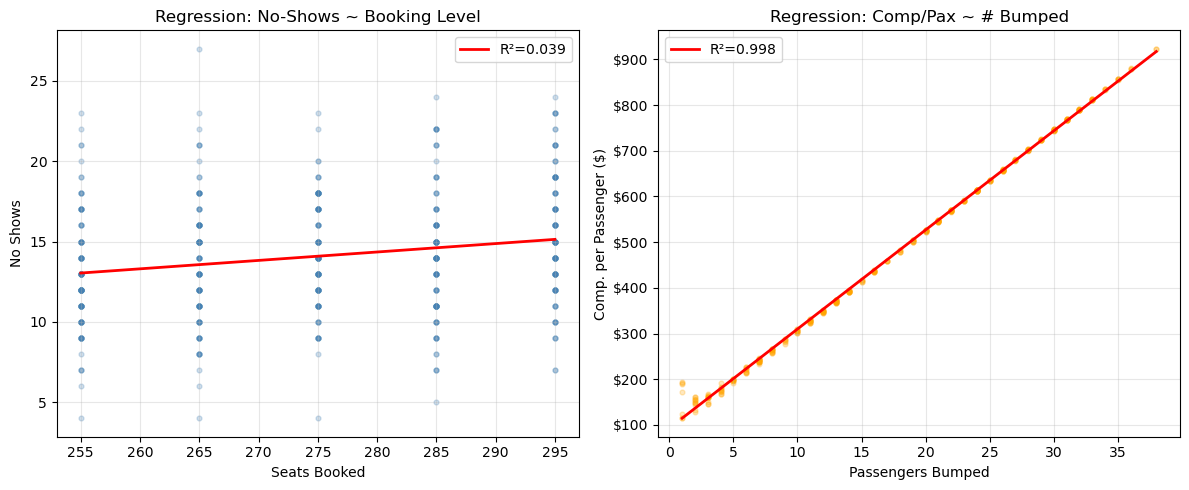


=== Monte Carlo Results (selected booking levels) ===
 Booked  Exp Profit  Std Dev  P(loss) %   P5 ($)  P95 ($)  Avg Bumped
    250    72,320.3  2,227.1        0.0 68,651.5 75,946.6         0.0
    255    75,174.4  2,179.8        0.0 71,563.8 78,888.3         0.0
    260    77,740.7  1,804.5        0.0 74,395.2 79,936.4         0.4
    265    79,001.6    990.5        0.0 76,939.5 79,959.2         2.3
    270    78,257.5  1,359.4        0.0 75,597.5 79,850.1         6.2
    275    76,132.9  2,116.8        0.0 72,187.3 79,058.2        10.9
    280    72,958.6  2,895.7        0.0 67,726.7 77,147.7        15.6
    285    68,816.3  3,659.2        0.0 62,323.2 74,339.2        20.4
    290    63,646.6  4,394.1        0.0 55,939.3 70,361.1        25.1
    295    57,560.4  5,188.3        0.0 48,580.9 65,627.8        29.9
    300    50,491.1  5,924.0        0.0 40,255.5 59,768.9        34.6
    305    42,499.6  6,703.5        0.0 31,005.0 52,967.0        39.3
    310    33,533.1  7,464.2       

In [42]:
#below are the stats libraries

from scipy import stats as sp_stats


#below are the regression models
#model 1 --> booked seats vs no-shows
#model 2 --> bumped pax vs compensation per bumped passenger


#model 1 --> use booked seats to estimate no-shows
slope_ns, intercept_ns, r_ns, _, _ = sp_stats.linregress(df['Booked'], df['No shows'])

#residual std --> shows how much actual no-shows vary around the regression line
resid_ns_std = (df['No shows'] - (intercept_ns + slope_ns * df['Booked'])).std()


#model 2 --> only look at rows where people were actually bumped
bdf = df[df['bumped'] > 0].copy()

#use # bumped to estimate compensation per bumped passenger
slope_cp, intercept_cp, r_cp, _, _ = sp_stats.linregress(bdf['bumped'], bdf['compensation per bumped passenger'])


#residual std --> variation around compensation regression line
resid_cp_std = (bdf['compensation per bumped passenger'] - (intercept_cp + slope_cp * bdf['bumped'])).std()


#below are the print statements for both regression models
print("=== Regression Model 1: No-Shows ~ Booked ===")


#print model 1 --> intercept + slope + R^2 + residual std
print(f"  No_shows = {intercept_ns:.3f} + {slope_ns:.4f} × Booked   |   R² = {r_ns**2:.4f}  |  σ_resid = {resid_ns_std:.2f}")

print(f"\n=== Regression Model 2: Comp/Pax ~ # Bumped ===")


#print model 2 --> intercept + slope + R^2 + residual std
print(f"  Comp/pax = {intercept_cp:.2f} + {slope_cp:.3f} × bumped   |   R² = {r_cp**2:.4f}  |  σ_resid = ${resid_cp_std:.2f}")


#below are the regression graphs
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


#x values for first regression line --> booked seats range
g1 = np.linspace(df['Booked'].min(), df['Booked'].max(), 200)


#left graph --> actual booked seats vs no-shows
axes[0].scatter(df['Booked'], df['No shows'], alpha=0.25, s=12, color='steelblue')

#left graph regression line --> predicted no-shows
axes[0].plot(g1, intercept_ns + slope_ns * g1, 'r-', lw=2, label=f'R²={r_ns**2:.3f}')


#left graph labels + title
axes[0].set_title('Regression: No-Shows ~ Booking Level')
axes[0].set_xlabel('Seats Booked'); axes[0].set_ylabel('No Shows')
axes[0].legend(); axes[0].grid(alpha=0.3)


#x values for second regression line --> bumped passenger range
g2 = np.linspace(bdf['bumped'].min(), bdf['bumped'].max(), 200)


#right graph --> actual bumped pax vs comp per pax
axes[1].scatter(bdf['bumped'], bdf['compensation per bumped passenger'], alpha=0.25, s=12, color='orange')

#right graph regression line --> predicted comp per bumped pax
axes[1].plot(g2, intercept_cp + slope_cp * g2, 'r-', lw=2, label=f'R²={r_cp**2:.3f}')


#right graph labels + title
axes[1].set_title('Regression: Comp/Pax ~ # Bumped')
axes[1].set_xlabel('Passengers Bumped'); axes[1].set_ylabel('Comp. per Passenger ($)')

#format y-axis --> dollar values
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))


#right graph legend + grid
axes[1].legend(); axes[1].grid(alpha=0.3)


#clean layout and show graph
plt.tight_layout(); plt.show()


#monte carlo simulation
#go through each booking level from 250 to 310
#for each level --> simulate 20,000 flights
#each simulated flight uses:
#   no-shows from regression + random noise
#   comp/pax from regression + random noise
#then calculate profit for each flight and average it

np.random.seed(42)


#number of simulations and booking levels to test
N_SIM = 20_000
booking_range_sim = np.arange(250, 311)
sim_results = []


#loop through each possible booking level
for B in booking_range_sim:
    
    #estimate no-shows for this booking level
    mean_ns = intercept_ns + slope_ns * B

    #add random noise to no-shows and keep value between 0 and booked seats
    no_shows = np.clip(mean_ns + np.random.normal(0, resid_ns_std, N_SIM), 0, B)


    #show-ups --> booked minus no-shows
    show_ups = B - no_shows

    #bumped --> any show-ups above actual plane capacity
    bumped = np.maximum(0.0, show_ups - SEATS)

    #boarded --> passengers who actually get on plane
    boarded = show_ups - bumped


    #estimate compensation per bumped passenger
    mean_cp = intercept_cp + slope_cp * bumped

    #add random noise to compensation and keep it nonnegative
    comp_per_pax = np.maximum(0.0, mean_cp + np.random.normal(0, resid_cp_std, N_SIM))

    #total compensation --> bumped passengers times comp per pax
    total_comp = bumped * comp_per_pax


    #profit --> ticket revenue from boarded pax minus compensation minus fixed cost
    profits = boarded * TICKET_REVENUE - total_comp - FIXED_COST


    #save results for this booking level
    sim_results.append({'Booked': int(B),'Exp Profit': profits.mean(),'Std Dev': profits.std(),'P(loss) %': (profits < 0).mean() * 100,
        'P5 ($)': np.percentile(profits, 5),'P95 ($)': np.percentile(profits, 95),'Avg Bumped': bumped.mean(),})


#turn simulation results into dataframe
sim_df = pd.DataFrame(sim_results)


#find row with highest expected profit
optimal = sim_df.loc[sim_df['Exp Profit'].idxmax()]


#get optimal booking level as integer
opt_B = int(optimal['Booked'])


#print selected booking levels
print("\n=== Monte Carlo Results (selected booking levels) ===")


#booking levels shown in final table
show_Bs = [250, 255, 260, 265, 270, 275, 280, 285, 290, 295, 300, 305, 310]

#columns shown in final table
cols = ['Booked','Exp Profit','Std Dev','P(loss) %','P5 ($)','P95 ($)','Avg Bumped']


#print table with selected results
print(sim_df[sim_df['Booked'].isin(show_Bs)][cols].to_string(
    index=False, float_format=lambda x: f'{x:,.1f}'))


#print final optimal recommendation values
print(f"\n{'─'*55}")
print(f"  OPTIMAL BOOKING LEVEL  :  {opt_B} seats")
print(f"  Expected profit        :  ${optimal['Exp Profit']:,.0f}")
print(f"  Std deviation          :  ${optimal['Std Dev']:,.0f}")
print(f"  Probability of loss    :  {optimal['P(loss) %']:.1f}%")
print(f"  Expected pax bumped    :  {optimal['Avg Bumped']:.1f}")
print(f"{'─'*55}")

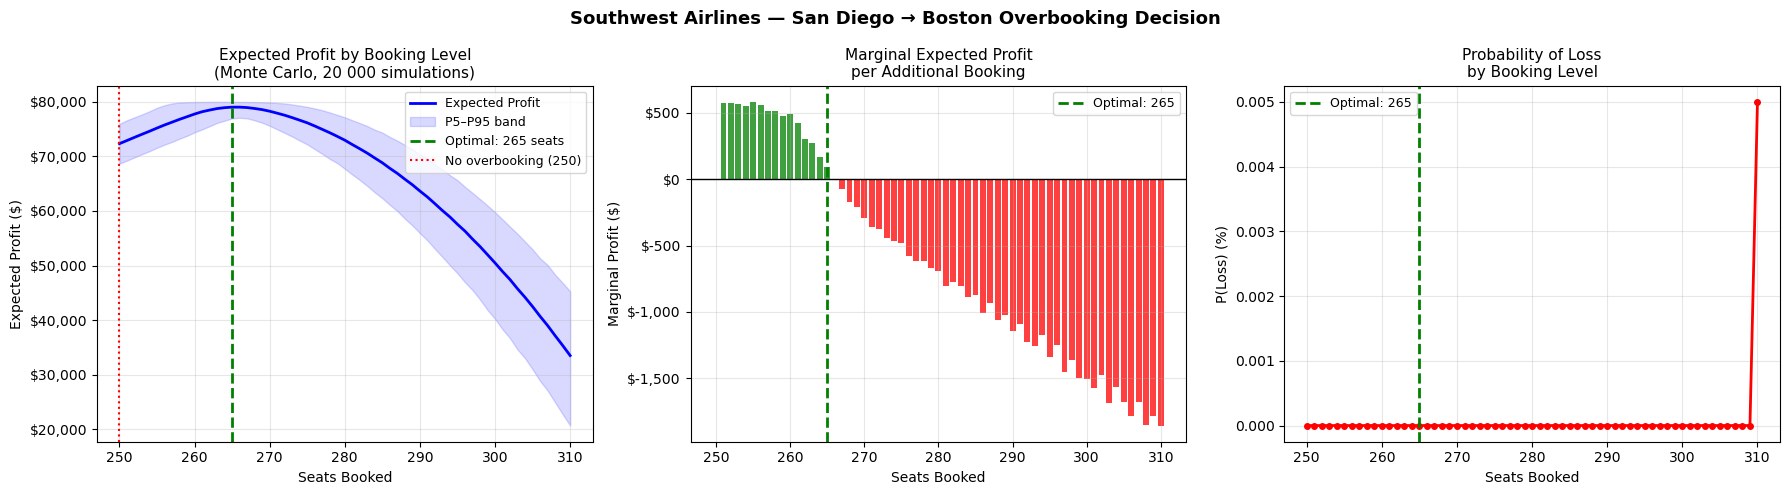

   RECOMMENDATION: HOW MANY TICKETS SHOULD SOUTHWEST BOOK?

  Optimal booking level  : 265 seats
  Plane capacity         : 250 seats
  Overbooking amount     : 15 extra tickets (6.0% above capacity)

  Expected daily profit  : $    79,002
  vs. no overbooking     : $    72,320
  Daily profit gain      : $     6,681
  Annual profit gain     : $ 2,438,671

  Risk profile at optimal booking level:
    Expected pax bumped  : 2.3 per flight
    Probability of loss  : 0.0%
    5th-pct profit       : $76,940
    Std deviation        : $990



In [44]:
#final visualization and recommendation
#3 graphs below --> expected profit, marginal profit, and loss probability

#format dollar values on graph axes
fmt_d = mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')

#make 1 row with 3 graphs
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


#graph 1 --> expected profit across booking levels
ax = axes[0]

#plot expected profit line
ax.plot(sim_df['Booked'], sim_df['Exp Profit'], 'b-', lw=2, label='Expected Profit')

#shaded area --> 5th percentile to 95th percentile profit range
ax.fill_between(sim_df['Booked'], sim_df['P5 ($)'], sim_df['P95 ($)'], alpha=0.15, color='blue', label='P5–P95 band')

#green line --> optimal booking level
ax.axvline(opt_B, color='green', ls='--', lw=2, label=f'Optimal: {opt_B} seats')

#red line --> no overbooking case with only 250 seats booked
ax.axvline(250, color='red', ls=':', lw=1.5, label='No overbooking (250)')

#titles and labels for expected profit graph
ax.set_title('Expected Profit by Booking Level\n(Monte Carlo, 20 000 simulations)', fontsize=11)
ax.set_xlabel('Seats Booked')
ax.set_ylabel('Expected Profit ($)')

#format y-axis as dollars
ax.yaxis.set_major_formatter(fmt_d)

#legend and grid
ax.legend(fontsize=9)
ax.grid(alpha=0.3)


#graph 2 --> marginal profit from each extra booking
#diff() --> compares profit to the previous booking level
sim_df['Marginal Profit'] = sim_df['Exp Profit'].diff()

#green bars --> positive marginal profit
#red bars --> negative marginal profit
bar_colors = ['green' if v >= 0 else 'red' for v in sim_df['Marginal Profit'].fillna(1)]

ax = axes[1]

#bar chart for marginal profit
ax.bar(sim_df['Booked'], sim_df['Marginal Profit'].fillna(0), color=bar_colors, alpha=0.75)

#black line --> break-even point for marginal profit
ax.axhline(0, color='black', lw=1)

#green line --> optimal booking level
ax.axvline(opt_B, color='green', ls='--', lw=2, label=f'Optimal: {opt_B}')

#titles and labels for marginal profit graph
ax.set_title('Marginal Expected Profit\nper Additional Booking', fontsize=11)
ax.set_xlabel('Seats Booked')
ax.set_ylabel('Marginal Profit ($)')

#format y-axis as dollars
ax.yaxis.set_major_formatter(fmt_d)

#legend and grid
ax.legend(fontsize=9)
ax.grid(alpha=0.3)


#graph 3 --> probability of loss for each booking level
ax = axes[2]

#plot loss probability line
ax.plot(sim_df['Booked'], sim_df['P(loss) %'], 'r-o', ms=4, lw=2)

#green line --> optimal booking level
ax.axvline(opt_B, color='green', ls='--', lw=2, label=f'Optimal: {opt_B}')

#titles and labels for loss probability graph
ax.set_title('Probability of Loss\nby Booking Level', fontsize=11)
ax.set_xlabel('Seats Booked')
ax.set_ylabel('P(Loss) (%)')

#legend and grid
ax.legend(fontsize=9)
ax.grid(alpha=0.3)


#overall title for all 3 graphs
plt.suptitle('Southwest Airlines — San Diego → Boston Overbooking Decision',
             fontsize=13, fontweight='bold')

#clean layout and save graph
plt.tight_layout()
plt.show()


#summary recommendation
#compare optimal booking level vs no-overbooking case

#expected profit when only 250 seats are booked
profit_no_ob = sim_df[sim_df['Booked'] == 250]['Exp Profit'].values[0]

#daily gain --> optimal profit minus no-overbooking profit
daily_gain = optimal['Exp Profit'] - profit_no_ob

#annual gain --> daily gain times 365 flights
annual_gain = daily_gain * 365


#print final recommendation
print("=" * 65)
print("   RECOMMENDATION: HOW MANY TICKETS SHOULD SOUTHWEST BOOK?")
print("=" * 65)

#print final values --> optimal seats, profit, and risk numbers
print(f"""
  Optimal booking level  : {opt_B} seats
  Plane capacity         : {SEATS} seats
  Overbooking amount     : {opt_B - SEATS} extra tickets ({(opt_B-SEATS)/SEATS*100:.1f}% above capacity)

  Expected daily profit  : ${optimal['Exp Profit']:>10,.0f}
  vs. no overbooking     : ${profit_no_ob:>10,.0f}
  Daily profit gain      : ${daily_gain:>10,.0f}
  Annual profit gain     : ${annual_gain:>10,.0f}

  Risk profile at optimal booking level:
    Expected pax bumped  : {optimal['Avg Bumped']:.1f} per flight
    Probability of loss  : {optimal['P(loss) %']:.1f}%
    5th-pct profit       : ${optimal['P5 ($)']:,.0f}
    Std deviation        : ${optimal['Std Dev']:,.0f}
""")

#print ending line
print("=" * 65)